Clean sheet notebook on wolf 1130 https://ui.adsabs.harvard.edu/abs/2018ApJ...854..145M/abstract

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import os
import glob
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
import astropy.constants as const
from astropy.modeling import models, fitting
import lightkurve as lk
from scipy.interpolate import interp1d
from astropy.convolution import convolve, Box1DKernel


#matplotlib set up
%matplotlib inline
from matplotlib import rcParams
rcParams["figure.figsize"] = (14, 5)
rcParams["font.size"] = 20

Extracted and corrected spectra, but HASP won't add them. Why? Need to fix DQs to remove slit loss keywords?

In [3]:
path = 'data/reextractions/'
sx1s = glob.glob('{}*fixed_sx1.fits'.format(path))
sx1s

['data/reextractions/o8ru2h020_fixed_sx1.fits',
 'data/reextractions/o8ru2h010_fixed_sx1.fits']

data/reextractions/o8ru2h020_fixed_sx1.fits
G230LB
data/reextractions/o8ru2h010_fixed_sx1.fits
G230LB


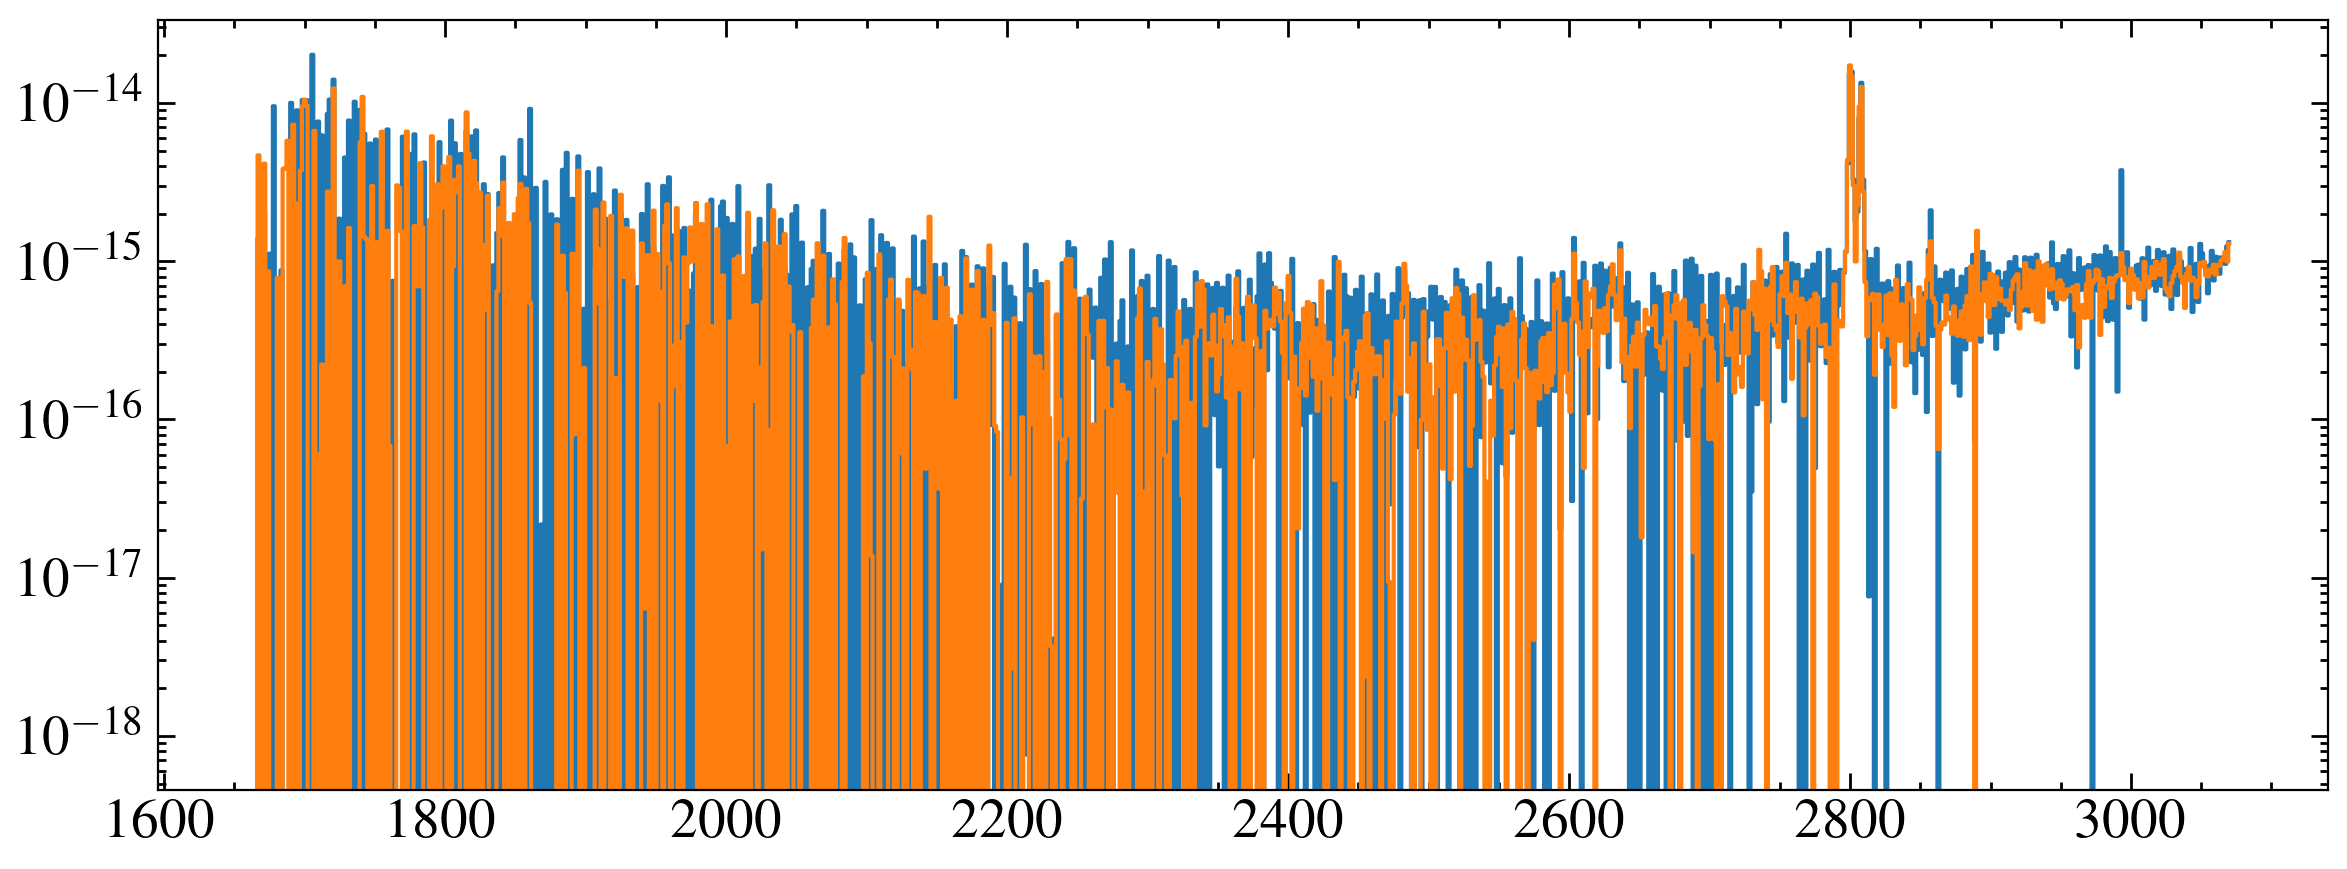

In [8]:
fig, ax = plt.subplots()

for x in sx1s:
    print(x)
    grating = fits.getheader(x, 0)['OPT_ELEM'] 
    print(grating)
    data = fits.getdata(x, 1)[0]
    # print(data['A2Center'])
    w, f, e= data['WAVELENGTH'], data['FLUX'], data['ERROR']

    ax.step(w, f, where='mid')
    # ax.step(w, e, where='mid', alpha=0.5)

    # if grating == 'G230LB':
        # ax.set_ylim(-1e-14, 1e-13)
    # plt.show()
ax.set_yscale('log')


data/reextractions/o8ru2h020_fixed_sx1.fits
NORMAL
G230LB
[2048 2064 2304 2320 2560 2576 3072 3088]
data/reextractions/o8ru2h010_fixed_sx1.fits
NORMAL
G230LB
[2048 2064 2304 2320 2560 2576 3072 3088]


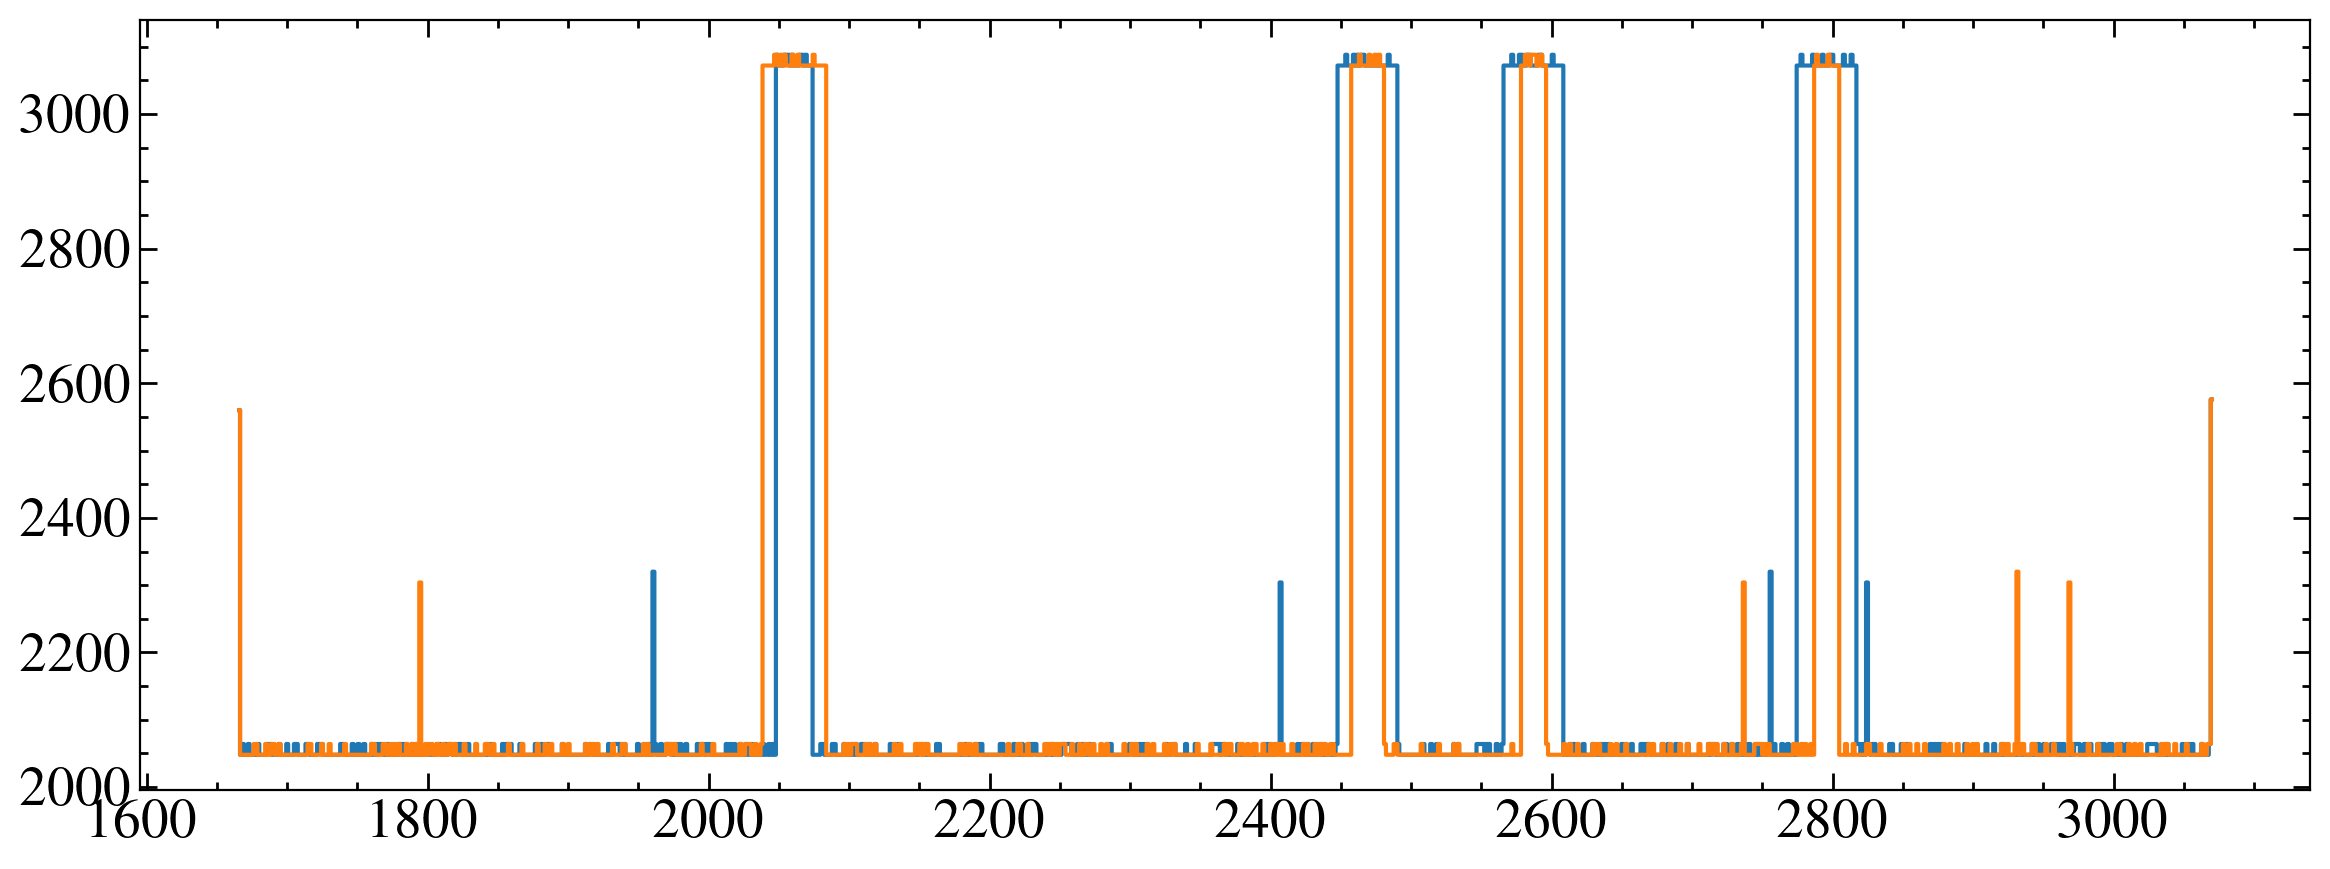

In [14]:
fig, ax = plt.subplots()

for x in sx1s:
    print(x)
    print(fits.getheader(x, 1)['EXPFLAG'])
    grating = fits.getheader(x, 0)['OPT_ELEM'] 
    print(grating)
    data = fits.getdata(x, 1)[0]
    w, f, e, dq= data['WAVELENGTH'], data['FLUX'], data['ERROR'],  data['DQ']

    dqi = np.copy(dq)
    for i in range(len(dqi)):
        if dqi[i] >= 16384:
            dqi[i] -= 16384
    ax.step(w, dqi, where='mid')
    print(np.unique(dqi))

# ax.set_yscale('log')


Just delete all dqs, much easier than mucking around with which ones to keep

In [17]:
for x in sx1s:
    print(x)
    hdul = fits.open(x)
    root = hdul[0].header['ROOTNAME']
    dq = hdul[1].data[0]['DQ']
    # print(len(dq))
    dq = np.zeros(len(dq))
    hdul[1].data[0]['DQ'] = dq
    hdul.writeto('{}hasp/{}_fixed_dqs_sx1.fits'.format(path, root), overwite=True)
    hdul.close()

data/reextractions/o8ru2h020_fixed_sx1.fits
data/reextractions/o8ru2h010_fixed_sx1.fits


In [16]:
path

'data/reextractions/'

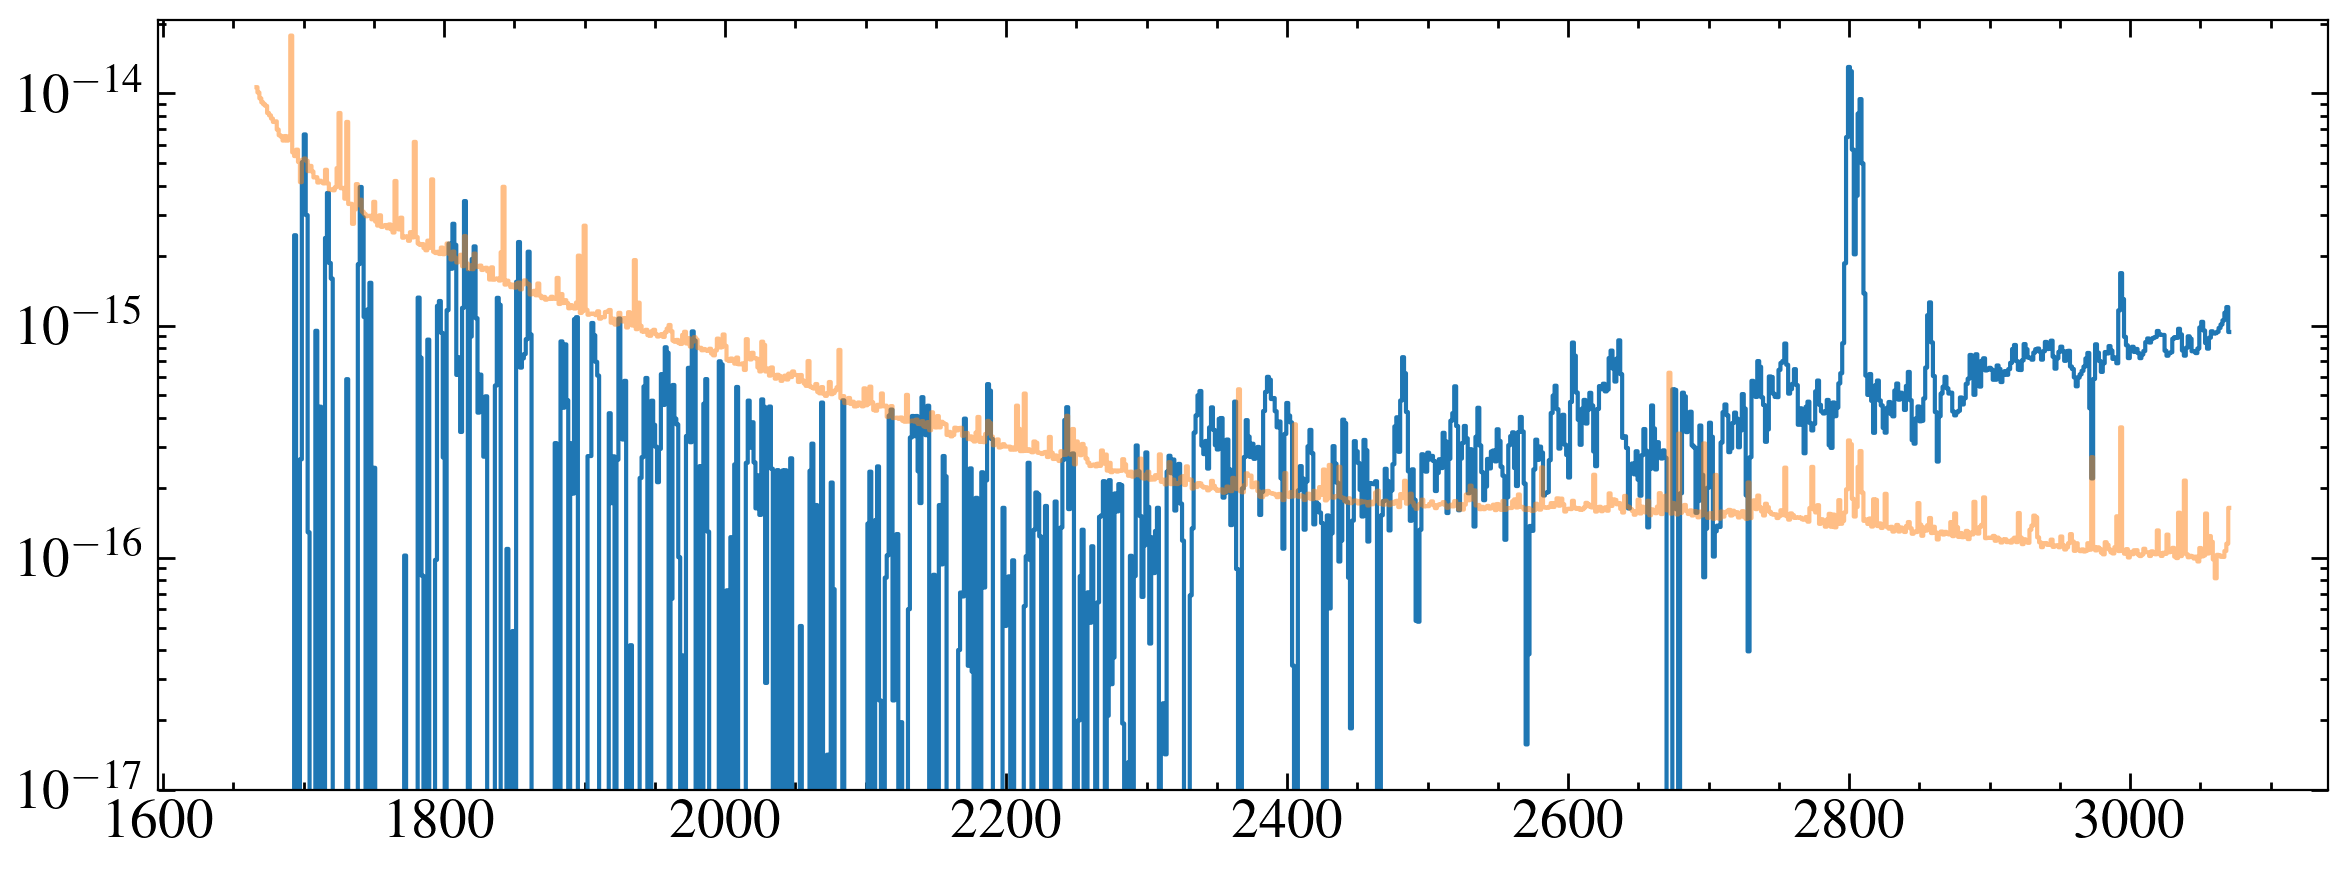

In [32]:
cpath = '/home/david/work/carmenes_binary/data/reextractions/hasp/output/hst_9786_stis_lhs482_g230lb_o8ru_cspec.fits'

fig, ax = plt.subplots()

data = fits.getdata(cpath, 1)[0]
w, f, e= data['WAVELENGTH'], data['FLUX'], data['ERROR']
fi = convolve(f,  Box1DKernel(2))

ax.step(w,fi, where='mid')
ax.step(w,e, where='mid', alpha=0.5)


ax.set_ylim(1e-17)
ax.set_yscale('log')

nw, nf, ne = w, f, e

Stick it onto the lowlib spectrum

In [27]:
lowpath = '/media/david/2tb_ext_hd/hddata/carmenes_binary/wolf1130/hst/hlsp/'
lowdata = fits.getdata('{}hlsp_lowlib_hst_stis_lhs482_g230lb-g430l-g750l_v1.0_spect.fits'.format(lowpath), 1)

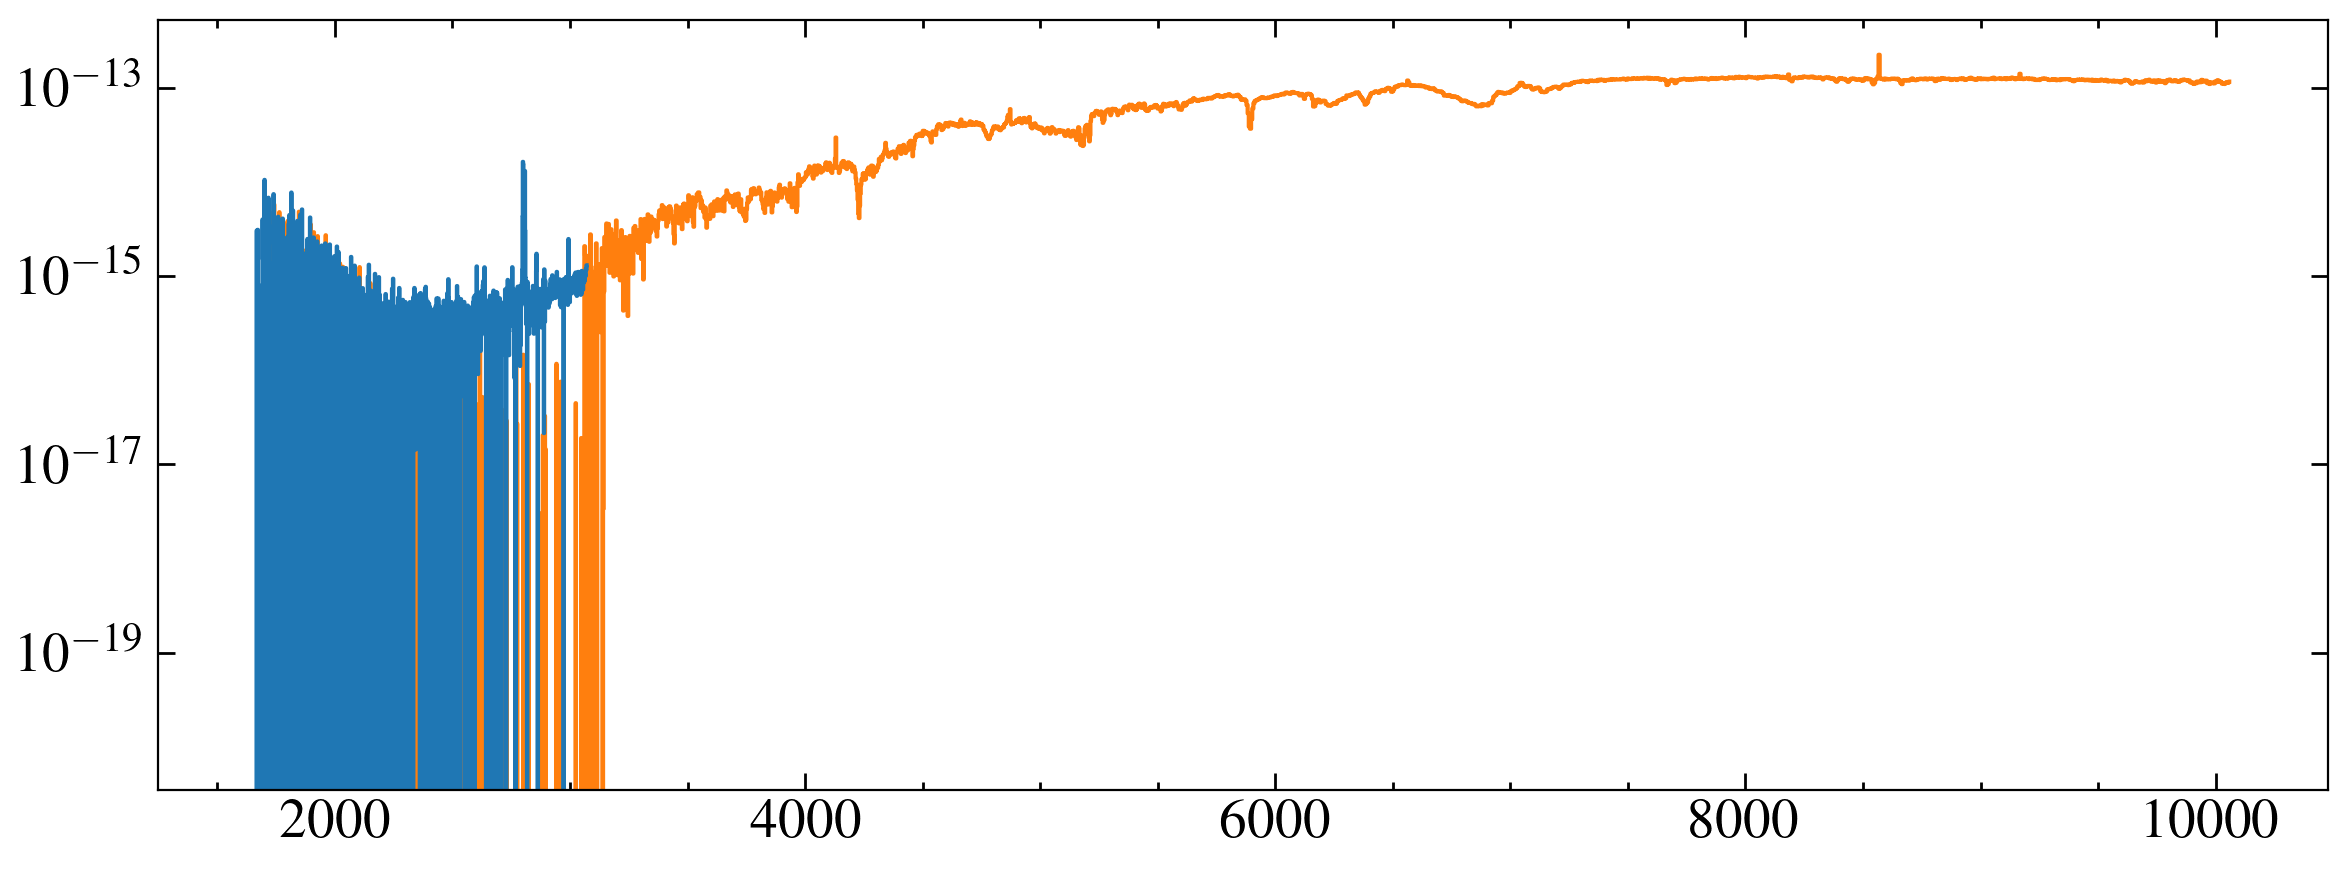

In [36]:
sw, sf, se = lowdata['Wavelength'], lowdata['Scattered Light & Slit Offcenter Corrected'], lowdata['Error_scattered_slit']


fig, ax = plt.subplots()

ax.step(nw,nf, where='mid')
ax.step(sw,sf, where='mid', zorder=-1)

ax.set_yscale('log')

w = np.hstack((nw, sw[sw > nw[-1]]))
f = np.hstack((nf, sf[sw > nw[-1]]))
e = np.hstack((ne, se[sw > nw[-1]]))

# ax.step(w, f, where='mid')

# spec = Table([w, f, e], names=['WAVELENGTH', 'FLUX', 'ERROR'])
# spec.write('data/wolf1130_stis_fixed_v2.csv', format='csv', overwrite=True)

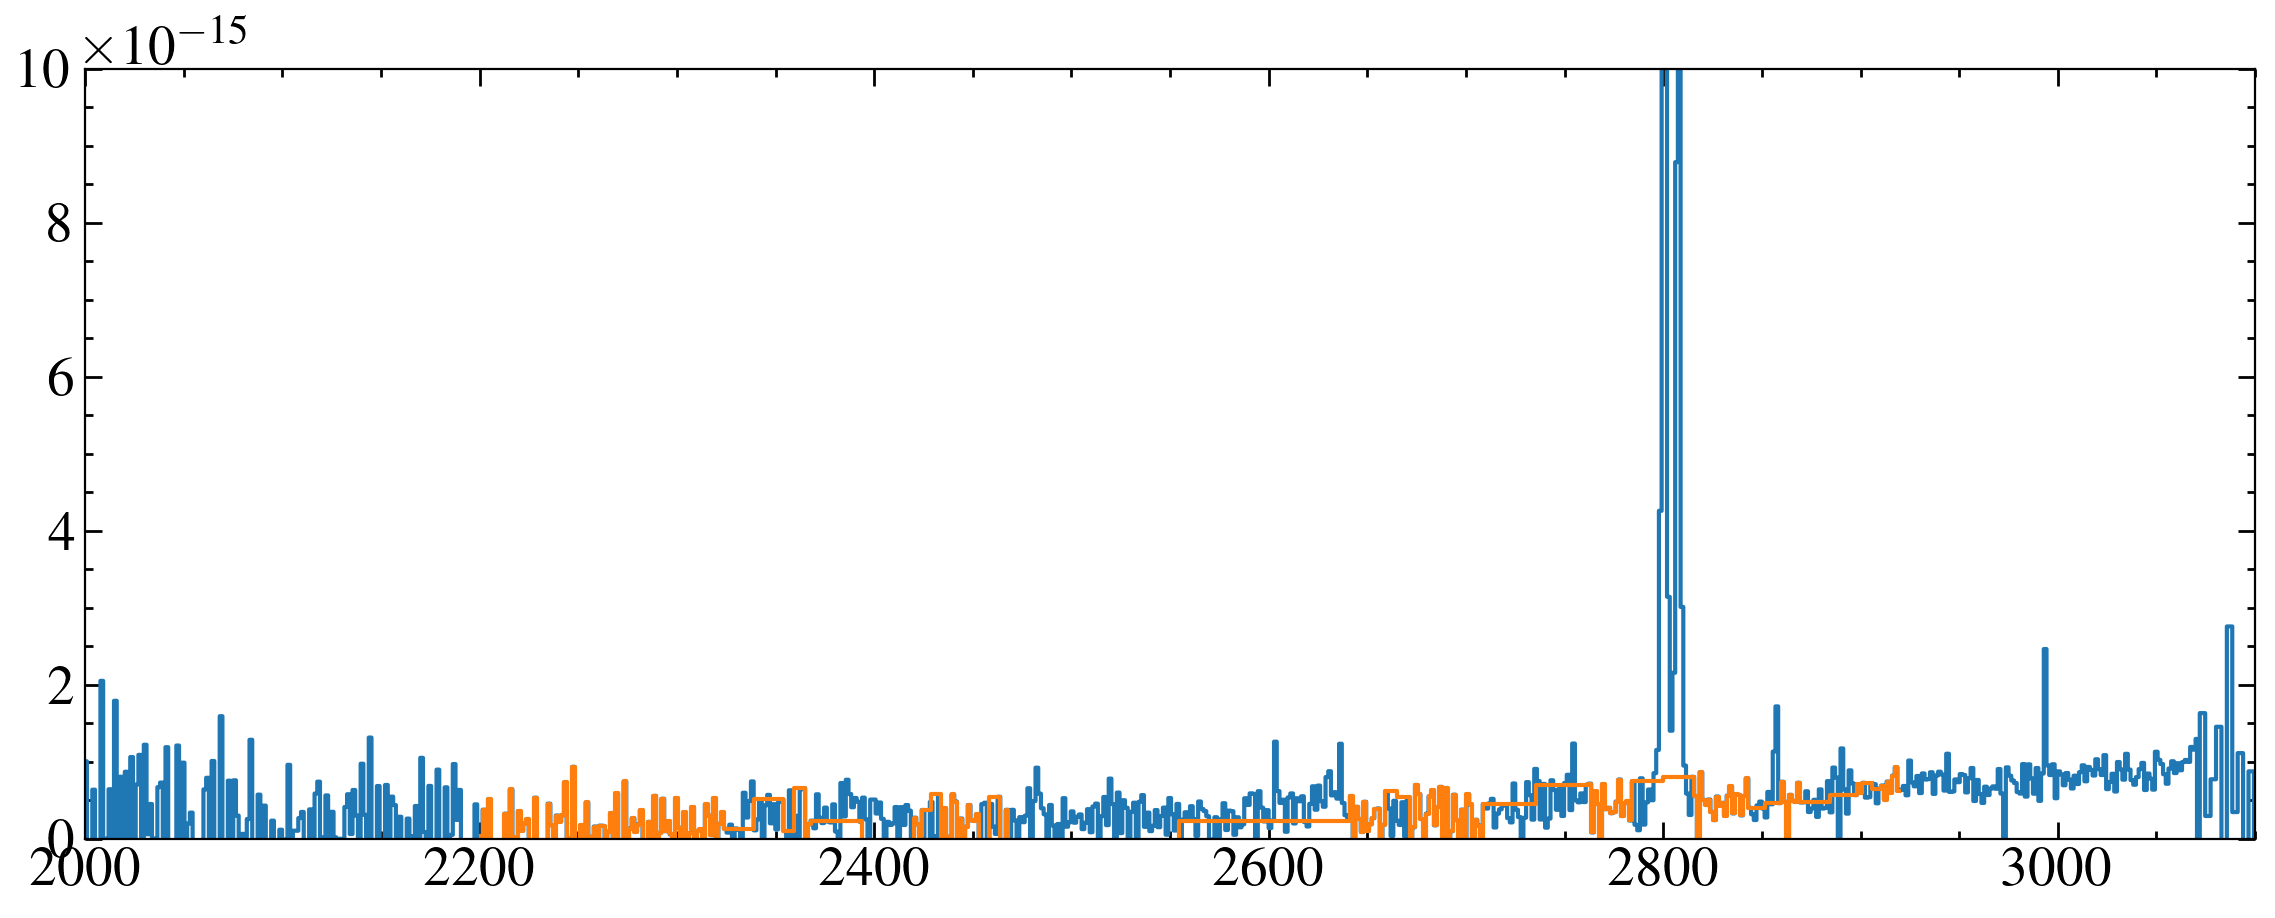

In [37]:
def mask_maker(x, pairs, include=True):
    """
    creates a mask for a spectrum that excudes between pairs from an array
    """
    b = pairs[::2]
    r = pairs[1::2]
    C = np.zeros_like(x,dtype='bool')
    for i in range(len(b)):
        C |= (x>b[i])&(x<r[i])
    if include:
        return ~C
    else:
        return C

cmaskbrs = [2200, 2325, 2353, 2356, 2364, 2369, 2418, 2425, 2432, 2455, 2463, 2470, 2640, 2660, 2670, 2710, 2761, 2785,
           2814, 2845, 2858, 2872, 2897, 2902, 2909, 2920]


fig, ax = plt.subplots()

mask = mask_maker(w, cmaskbrs, include=False)
cw, cf = w[mask], f[mask]

ax.step(w, f, where='mid')
ax.step(cw, cf, where ='mid')

# ax.set_yscale('log')
ax.set_ylim(0, 1e-14)
ax.set_xlim(2000, 3100)

b = cmaskbrs[::2]
r = cmaskbrs[1::2]

# pairs = Table([b, r], names=['W0', 'W1'])
# pairs.write('gj207d1_continuum_v01.csv', format='csv', overwrite=True)